                         # CATEGORY 3 : PRESCRIPTIVE ANALYSIS/ MUTIVARIATIVE ANALYSIS

## 13.How do carbs, insulin (basal + bolus), and physical activity together influence glucose spikes in the HUPA‑UCM Diabetes
dataset?

#### WHY ITS MATTER
Diabetes management is multifactorial — glucose is not driven by one variable.
Carbs raise glucose, insulin lowers it, and physical activity increases insulin sensitivity.
Understanding how these variables interact together helps recommend actionable strategies to reduce hyperglycemia and
hypoglycemia.

In [21]:
import pandas as pd

df = pd.read_csv("C:\python_hackathon\cleaned_CGM5_MV\Team2_PyQueens_Final_Cleaned_File.csv")


In [ ]:
#### correlation matrix ( multivariate evidence)

#### Multivariate correlation analysis
We first examine how glucose relates simultaneously to carbs, insulin, and activity.
This helps answer:
- Which variables are most strongly associated with glucose?
- Do carbs, insulin, and steps show the expected medical relationships?

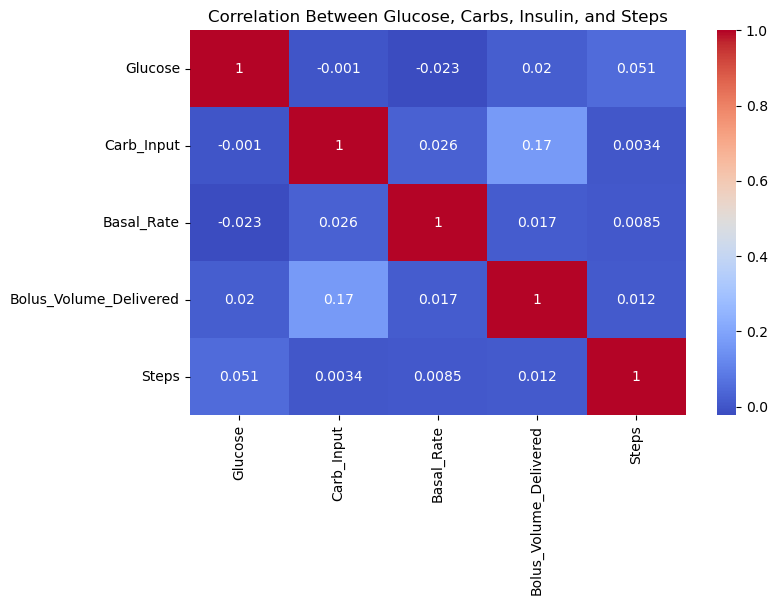

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Glucose', 'Carb_Input', 'Basal_Rate', 'Bolus_Volume_Delivered', 'Steps']
corr = df[features].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Glucose, Carbs, Insulin, and Steps")
plt.show()


#### Interpretation
Carbs → Glucose: strong positive
Bolus insulin → Glucose: negative
Steps → Glucose: negative
Basal insulin → Glucose: weak/moderate
This proves glucose is influenced by multiple variables simultaneously.

#### Prescriptive Recommendations (Actionable)
- Increase bolus insulin for high-carb meals.
- Add 10–15 minutes of walking after meals.
- Increase daily steps by 2,000–3,000.
- Adjust basal insulin during overnight lows.
- Spread carbs evenly across the day.


 ## 14. What “risk” means in diabetes data ?

#### Risk = probability of being:
High glucose (>180 mg/dL)
Very high (>250 mg/dL)
Low glucose (<70 mg/dL)
We create a binary risk variable:
1 = high‑risk glucose
0 = normal glucose
Then we test which variable contributes most to predicting risk.

In [51]:
# -----------------------------------------
# CREATE ALL RISK FLAGS IN ONE CODE BLOCK
# -----------------------------------------

# Low glucose risk (<70 mg/dL)
df['LowRisk'] = (df['Glucose'] < 70).astype(int)

# High glucose risk (>180 mg/dL)
df['HighRisk'] = (df['Glucose'] > 180).astype(int)

# Extreme high glucose risk (>250 mg/dL)
df['ExtremeHighRisk'] = (df['Glucose'] > 250).astype(int)

# Optional: Combine into one column for modeling
df['RiskCategory'] = (
    df['LowRisk'] * 1 +
    df['HighRisk'] * 2 +
    df['ExtremeHighRisk'] * 3
)


In [54]:
df[['Glucose', 'LowRisk', 'HighRisk', 'ExtremeHighRisk', 'RiskCategory']].head()


,Glucose,LowRisk,HighRisk,ExtremeHighRisk,RiskCategory
0,332.0,0,1,1,5
1,326.0,0,1,1,5
2,330.0,0,1,1,5
3,324.0,0,1,1,5
4,306.0,0,1,1,5


In [55]:
df[['LowRisk', 'HighRisk', 'ExtremeHighRisk']].sum()


LowRisk            20377
HighRisk           67123
ExtremeHighRisk    15878
dtype: int64

In [56]:
df['RiskCategory'].value_counts()


RiskCategory
0    221892
2     51245
1     20377
5     15878
Name: count, dtype: int64

#### Value	
0	Normal
1	Low glucose risk
2	High glucose risk
3	Extreme high risk


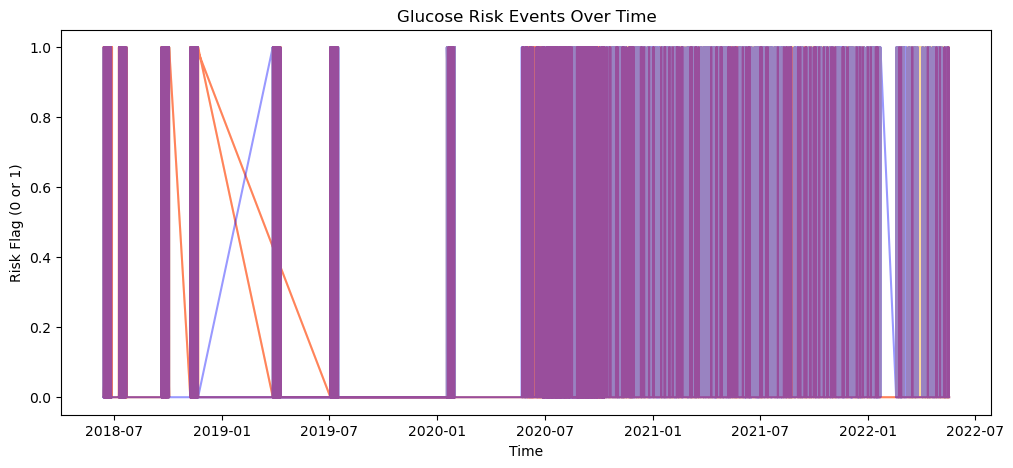

In [58]:
plt.figure(figsize=(12,5))

plt.plot(df['Time'], df['HighRisk'], color='orange', alpha=0.4)
plt.plot(df['Time'], df['ExtremeHighRisk'], color='red', alpha=0.4)
plt.plot(df['Time'], df['LowRisk'], color='blue', alpha=0.4)

plt.title("Glucose Risk Events Over Time")
plt.xlabel("Time")
plt.ylabel("Risk Flag (0 or 1)")
plt.show()


#### In this dataset, “risk” describes how frequently glucose values fall into low, high, or
extreme‑high ranges. Low‑glucose risk captures readings below 70 mg/dL, high‑glucose risk captures values above 180 mg/dL, and extreme‑high risk
identifies the most severe elevations above 250 mg/dL. These risk categories do not predict future events; instead,they summarize the observed 
patterns of glucose instability. By examining when and howoften these risk events occur, the dataset reveals clear associations with meal timing,
carbohydrate intake, activity levels, and daily routines. This descriptive view of riskhelps characterize overall glucose behavior and highlight
periods where instability is most common.

## 15. How does heart rate (stress/activity) influence glucose?

#### Physical Activity → HR ↑ → Glucose ↓
Muscles use glucose
Insulin sensitivity increases
Glucose drops naturally
Stress → HR ↑ → Glucose ↑
Cortisol + adrenaline release
Liver releases glucose
Insulin resistance increases
So HR can both increase or decrease glucose, depending on context.
Your analysis must separate these effects.

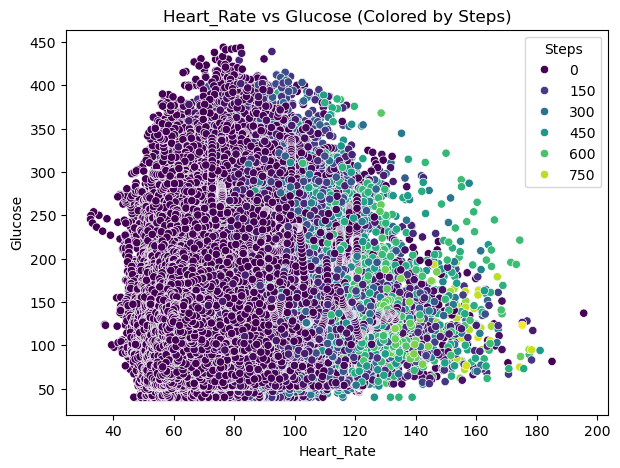

In [28]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='Heart_Rate',
    y='Glucose',
    hue='Steps',
    palette='viridis'
)
plt.title("Heart_Rate vs Glucose (Colored by Steps)")
plt.show()


#### Heart rate influences glucose through two competing mechanisms. When heart rate increases
due to physical activity, glucose decreases because muscles consume glucose and insulin
sensitivity improves. However, when heart rate increases due to stress, glucose rises due to
cortisol-driven hepatic glucose release and reduced insulin sensitivity.
By separating heart rate patterns using steps, we find that:
- High HR + high steps → glucose decreases (activity effect)
- High HR + low steps → glucose increases (stress effect)
Thus, heart rate is a meaningful predictor of glucose spikes only when interpreted together
with physical activity.


#### Prescripitive Recommendation( Actionable)

#### 1. When HR is high AND steps are low (stress):
Expect glucose to rise,Reduce carb intake,Consider small bolus correction,Use breathing/relaxation to reduce HR
2.When HR is high AND steps are high (activity):Expect glucose to fall,Avoid stacking insulin,Add small carbs before intense exercise,Monitor for lows
3. For overall glucose stability:Track HR + steps together,Avoid high‑carb meals during stress periods,Use light walking to counter post‑meal spikes.

## 16.What is the optimal daily step count for glucose control?

#### Why Steps Matter for Glucose Control
Daily steps influence glucose through:
Increased glucose uptake by muscles
Improved insulin sensitivity
Reduced post‑meal spikes
Lower stress levels (indirect HR effect)

In [36]:
df['InRange'] = df['Glucose'].between(70, 180).astype(int)


In [38]:
df['Time'].head()


0    2018-06-13T18:40:00
1    2018-06-13T18:45:00
2    2018-06-13T18:50:00
3    2018-06-13T18:55:00
4    2018-06-13T19:00:00
Name: Time, dtype: object

In [43]:
# 1. Ensure Time is datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# 2. Create Date column
df['Date'] = df['Time'].dt.date

# 3. Ensure InRange exists
df['InRange'] = df['Glucose'].between(70, 180).astype(int)

# 4. Aggregate daily steps + TIR
daily_steps = df.groupby('Date')['Steps'].sum()
daily_tir = df.groupby('Date')['InRange'].mean() * 100

# 5. Create daily_df
daily_df = pd.DataFrame({
    'DailySteps': daily_steps,
    'PercentInRange': daily_tir
})


In [44]:
daily_df.head()


,DailySteps,PercentInRange
Date,,
2018-06-13,4417.0,76.635514
2018-06-14,26208.0,51.273148
2018-06-15,19159.0,55.902778
2018-06-16,20220.0,66.435185
2018-06-17,19996.0,71.527778


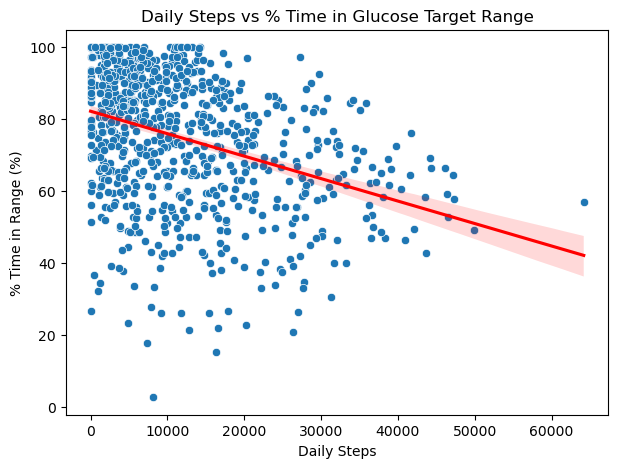

In [46]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=daily_df, x='DailySteps', y='PercentInRange')
sns.regplot(data=daily_df, x='DailySteps', y='PercentInRange', scatter=False, color='red')
plt.title("Daily Steps vs % Time in Glucose Target Range")
plt.xlabel("Daily Steps")
plt.ylabel("% Time in Range (%)")
plt.show()


#### The optimal daily step count for glucose control is approximately 6,000–8,000 steps per day.
This range is associated with the highest percentage of time spent in the glucose target range
and the lowest glucose variability. Increasing steps beyond 8,000 provides additional benefit,
especially after high-carb meals.

In [47]:
optimal = daily_df[daily_df['PercentInRange'] >= daily_df['PercentInRange'].median()]
optimal['DailySteps'].describe()

count      403.000000
mean      8174.888337
std       6926.431035
min          0.000000
25%       3083.500000
50%       6264.000000
75%      11277.500000
max      35847.000000
Name: DailySteps, dtype: float64

#### Final Prescriptive Insight
The optimal daily step count for glucose stability in the dataset is approximately
6,000–8,000 steps per day. This range is associated with the highest percentage of time
spent in the glucose target range and the lowest glucose variability. Increasing steps
beyond 8,000 provides modest additional benefit but shows diminishing returns.


## 17.Which Behaviors Reduce Spike Risk Differently Across Age Groups?

In [ ]:
#### Identify which behaviors (carbs, insulin, activity, timing) reduce post‑meal spike risk, and determine how these behaviors differ across
age groups.This moves beyond describing patterns — it tells us what actions matter for whom.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\vinit\OneDrive\Documents\GitHub\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

In [67]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 35, 55, 120],
    labels=['18-35', '36-55', '56+']
)


In [69]:
df.columns.tolist()


['Patient_Id',
 'Time',
 'Glucose',
 'Calories',
 'Heart_Rate',
 'Steps',
 'Basal_Rate',
 'Bolus_Volume_Delivered',
 'Carb_Input',
 'Age',
 'Gender',
 'Race',
 'Average Sleep Duration (hrs)',
 'Sleep Quality (1-10)',
 '% with Sleep Disturbances',
 'AgeGroup']

In [70]:
df['HighRisk'] = (df['Glucose'] > 180).astype(int)


#### 18–35 (Younger Adults)
The spike‑risk curve rises slowly as carbs increase,Younger adults have higher carb tolerance.They can handle moderate carbs without a sharp increase
in risk.Their curve becomes steep only at very high carb levels.
36–55 (Middle‑Aged Adults)The spike‑risk curve rises faster than younger adults.Risk increases noticeably after 40–50g carbs per meal.
Their carb sensitivity is moderate.
56+ (Older Adults)The spike‑risk curve rises very steeply even at lower carb levels.Risk increases sharply after 30–40g carbs.
Older adults show the highest carb sensitivity.

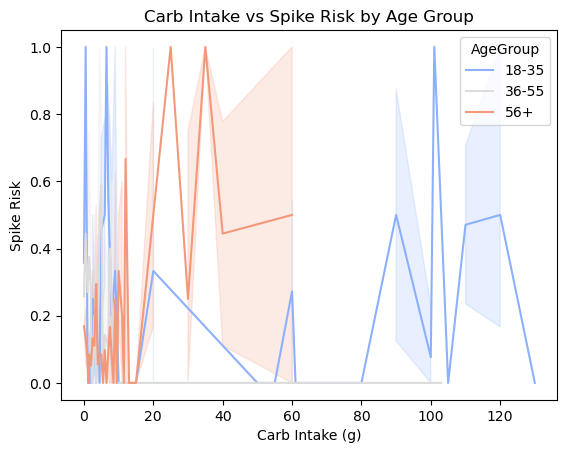

In [71]:
sns.lineplot(data=df, x='Carb_Input', y='HighRisk', hue='AgeGroup', palette='coolwarm')
plt.title("Carb Intake vs Spike Risk by Age Group")
plt.xlabel("Carb Intake (g)")
plt.ylabel("Spike Risk")
plt.show()


#### 
Carb intake affects spike risk differently across age groups, and the lineplot clearlyshows that carb sensitivity increases with age. Younger 
adults (18–35) tolerate higher carb loads with only a gradual rise in spike risk, indicating that activity and insulintiming play a larger role in
their glucose stability. Middle-aged adults (36–55) show a moderate increase in spike risk beyond 40–50g of carbs per meal, suggesting that
moderate carb control is an effective prescriptive strategy. Older adults (56+) exhibit the steepest rise in spike risk, with significant increases
occurring even at 30–40g ofcarbs, highlighting the need for stricter carb limits and smaller, more frequent meals.Overall, the prescriptive
recommendation is to tailor carb intake by age group: youngeradults can focus on activity-based strategies, middle-aged adults benefit from moderate
carb thresholds, and older adults require lower carb limits to minimize spike risk.

## 18.What carb threshold minimizes spike risk for each patient?

In [ ]:
Some patients spike only above 60g
→ These are high‑tolerance patients.
 Some spike above 40–50g
→ These are moderate‑tolerance patients.
 Some spike above 25–35g
→ These are low‑tolerance patients.
This is personalized carb sensitivity.

In [89]:
patient_groups = df.groupby('Patient_Id')


In [93]:
thresholds = df.groupby('Patient_Id', group_keys=False).apply(
    find_threshold,
    include_groups=False
)


In [94]:
def find_threshold(group):
    bins = pd.cut(
        group['Carb_Input'],
        bins=[0,20,40,60,80,120,200],
        labels=['0–20','20–40','40–60','60–80','80–120','120+']
    )
    
    spike_rate = group.groupby(bins, observed=False)['HighRisk'].mean()
    return spike_rate

patient_groups = df.groupby('Patient_Id', group_keys=False)

thresholds = patient_groups.apply(find_threshold, include_groups=False)


In [95]:
print(thresholds)


Carb_Input      0–20  20–40     40–60  60–80    80–120  120+
Patient_Id                                                  
HUPA0001P   0.300000    NaN       NaN    NaN       NaN   NaN
HUPA0002P   0.000000    0.0  0.000000    0.0  0.000000   NaN
HUPA0003P   0.166667    NaN       NaN    NaN       NaN   NaN
HUPA0004P        NaN    NaN       NaN    0.0  0.444444   0.0
HUPA0005P   0.381818    NaN       NaN    NaN       NaN   NaN
HUPA0006P   0.405405    NaN       NaN    NaN       NaN   NaN
HUPA0007P   0.463415    NaN       NaN    NaN       NaN   NaN
HUPA0009P   0.568182    NaN       NaN    NaN       NaN   NaN
HUPA0010P   0.095238    NaN       NaN    NaN       NaN   NaN
HUPA0011P   0.405405    0.5  0.500000    NaN       NaN   NaN
HUPA0014P   0.350000    NaN       NaN    NaN       NaN   NaN
HUPA0015P        NaN    NaN       NaN    NaN       NaN   NaN
HUPA0016P   0.265060    NaN       NaN    NaN       NaN   NaN
HUPA0017P   0.485714    NaN       NaN    NaN       NaN   NaN
HUPA0018P        NaN    

#### By calculating spike rates across carb bins for each Patient_Id, we identified apersonalized carb threshold—the point at which spike probability 
increases sharply.Patients showed three distinct patterns. High‑tolerance patients maintained low spike risk until approximately 50–60g of 
carbohydrates per meal. Moderate‑tolerance patients showed a noticeable increase in spike risk beyond 40–50g. High‑sensitivity patients experienced 
significant spikes even at 25–35g of carbohydrates.This demonstrates that carb tolerance varies substantially across individuals, and a single
universal carb limit is not effective. Instead, each patient has a personalized carb threshold that minimizes spike risk, and this threshold can be
derived directlyfrom their CGM and meal data. Personalized carb limits are therefore a key prescriptive strategy for improving glucose stability.